Libraries imported successfully!
Dataset Shape: (2926, 54)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2926 entries, 0 to 2925
Data columns (total 54 columns):
 #   Column                                                                                                                             Non-Null Count  Dtype  
---  ------                                                                                                                             --------------  -----  
 0   Country Name                                                                                                                       2926 non-null   object 
 1   Country Code                                                                                                                       2926 non-null   object 
 2   Years                                                                                                                              2926 non-null   int64  
 3   Access to clea

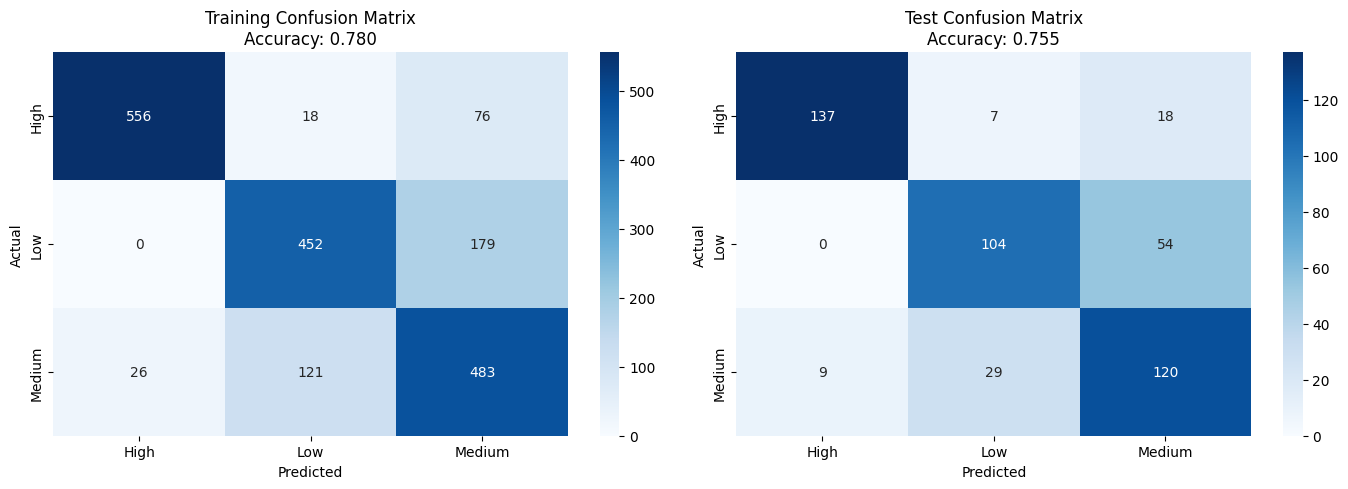

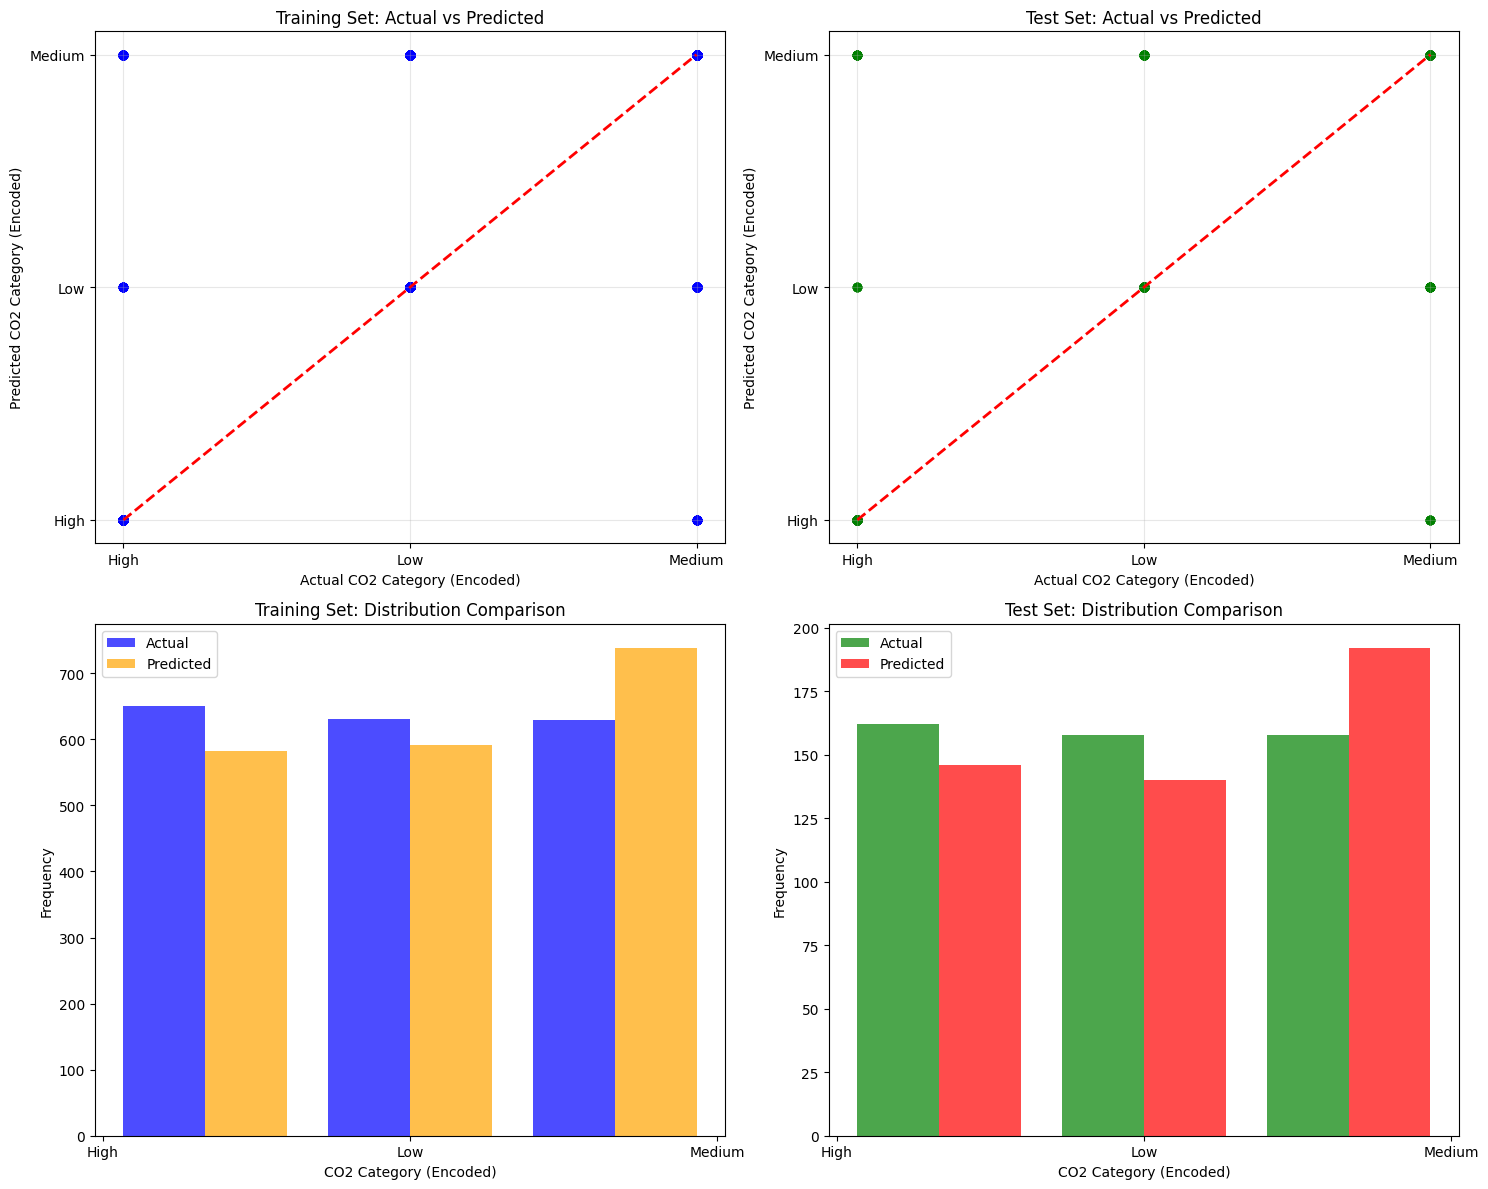

=== PREDICTION CONFIDENCE ANALYSIS ===
Training set - Mean confidence: 0.687
Training set - Std confidence: 0.209
Test set - Mean confidence: 0.684
Test set - Std confidence: 0.210


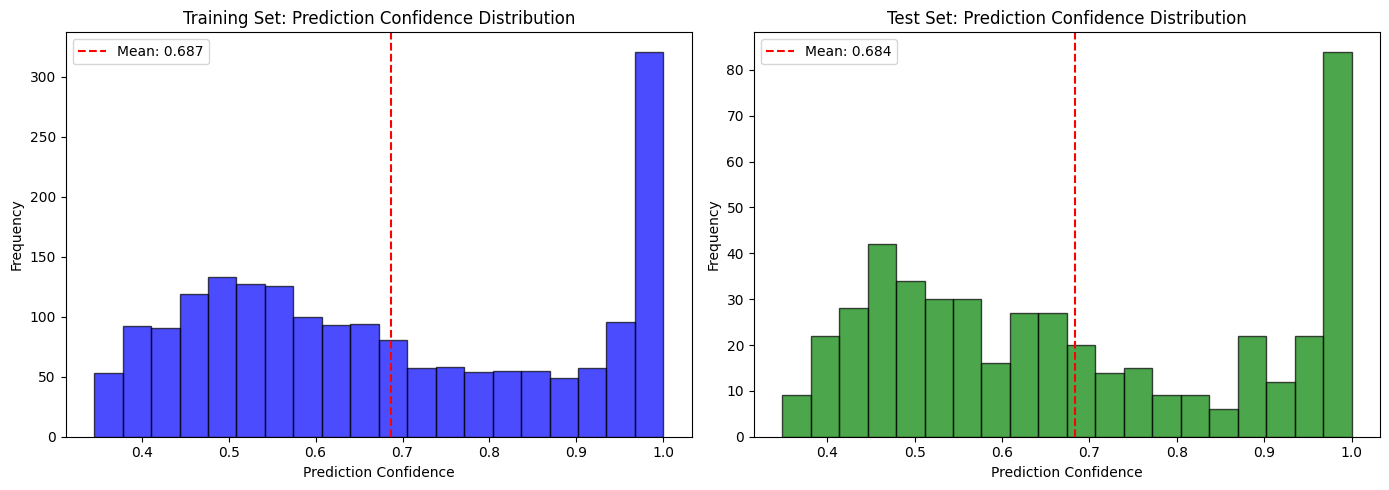

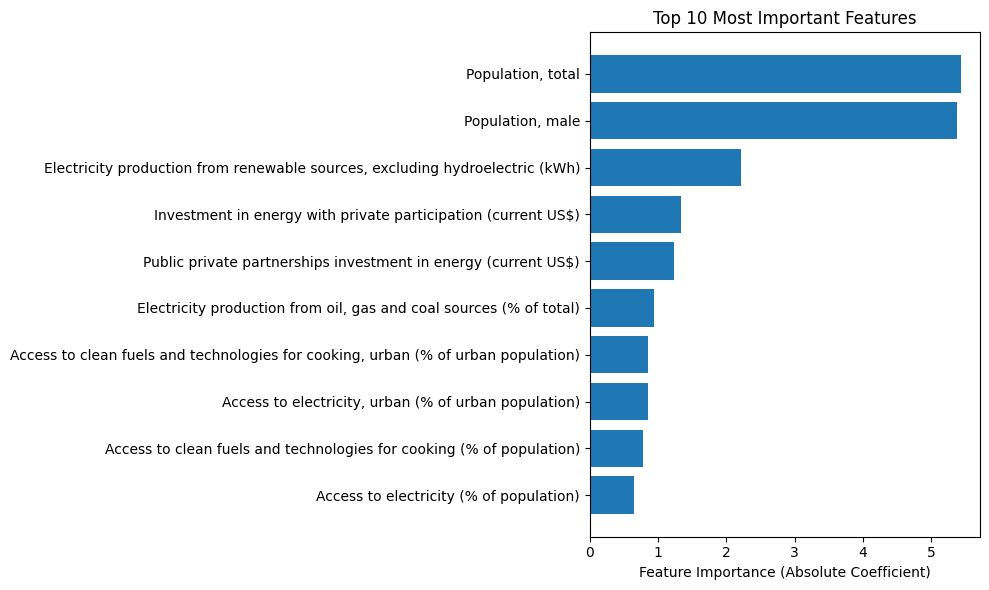

                 FINAL MODEL SUMMARY
Model Type: Logistic Regression (Multi-class)
Number of Features: 37
Number of Classes: 3
Class Labels: ['High', 'Low', 'Medium']

Dataset Size:
  - Total samples: 2389
  - Training samples: 1911
  - Test samples: 478

Model Performance:
  - Training Accuracy: 0.7802 (78.02%)
  - Test Accuracy: 0.7552 (75.52%)
  - Training Error Rate: 0.2198 (21.98%)
  - Test Error Rate: 0.2448 (24.48%)

Model Confidence:
  - Mean Training Confidence: 0.687
  - Mean Test Confidence: 0.684

✅ Model performance looks reasonable

Top 3 Most Important Features:
  1. Electricity production from renewable sources, excluding hydroelectric (kWh): 2.2187
  2. Population, male: 5.3806
  3. Population, total: 5.4423



In [3]:
# Cell 1: Install and Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('default')

print("Libraries imported successfully!")

# Cell 2: Load and Explore the Dataset
# Upload your dataset file in Google Colab first
# You can download it from the Kaggle link and upload to Colab

# Load the dataset
df = pd.read_csv('energy_data_II.csv')

print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

# Cell 3: Data Preprocessing and Feature Selection
# Check for CO2 emissions column
co2_column = None
for col in df.columns:
    if 'co2' in col.lower() or 'emission' in col.lower():
        co2_column = col
        break

if co2_column is None:
    print("CO2 emissions column not found. Available columns:")
    print(df.columns.tolist())
else:
    print(f"Found CO2 emissions column: {co2_column}")

# Select relevant features for energy sustainability prediction
feature_columns = []
for col in df.columns:
    col_lower = col.lower()
    if any(keyword in col_lower for keyword in ['renewable', 'energy', 'electricity', 'gdp', 'population', 'access']):
        if col != co2_column:  # Don't include target variable
            feature_columns.append(col)

print(f"\nSelected feature columns ({len(feature_columns)}):")
for col in feature_columns[:10]:  # Show first 10 features
    print(f"- {col}")
if len(feature_columns) > 10:
    print(f"... and {len(feature_columns) - 10} more features")

# Cell 4: Create Target Variable (Classification)
# Convert CO2 emissions to categorical variable
df_clean = df.copy()

# Remove rows where CO2 emissions is null
df_clean = df_clean.dropna(subset=[co2_column])

# Create categorical target based on CO2 emissions quantiles
co2_values = df_clean[co2_column]
q33 = co2_values.quantile(0.33)
q66 = co2_values.quantile(0.66)

def categorize_co2(value):
    if value <= q33:
        return 'Low'
    elif value <= q66:
        return 'Medium'
    else:
        return 'High'

df_clean['CO2_Category'] = df_clean[co2_column].apply(categorize_co2)

print("CO2 Emissions Distribution:")
print(f"Low: <= {q33:.2f} kt")
print(f"Medium: {q33:.2f} - {q66:.2f} kt")
print(f"High: > {q66:.2f} kt")
print("\nTarget variable distribution:")
print(df_clean['CO2_Category'].value_counts())

# Cell 5: Prepare Features and Handle Missing Values
# Select only the feature columns that exist in the dataset
existing_features = [col for col in feature_columns if col in df_clean.columns]
print(f"Using {len(existing_features)} features for modeling")

# Prepare feature matrix X and target vector y
X = df_clean[existing_features].copy()
y = df_clean['CO2_Category'].copy()

# Handle missing values in features
print("\nMissing values in features:")
missing_counts = X.isnull().sum()
print(missing_counts[missing_counts > 0])

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_labels = label_encoder.classes_
print(f"\nClass encoding: {dict(zip(range(len(class_labels)), class_labels))}")

print(f"\nFinal dataset shape: X={X_imputed.shape}, y={len(y_encoded)}")

# Cell 6: Split Data and Scale Features
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split completed:")
print(f"Training set: X={X_train_scaled.shape}, y={len(y_train)}")
print(f"Test set: X={X_test_scaled.shape}, y={len(y_test)}")

# Check class distribution in train/test sets
train_dist = pd.Series(y_train).value_counts().sort_index()
test_dist = pd.Series(y_test).value_counts().sort_index()
print(f"\nTraining set distribution: {dict(zip(class_labels, train_dist))}")
print(f"Test set distribution: {dict(zip(class_labels, test_dist))}")

# Cell 7: Train Logistic Regression Model
# Initialize and train the logistic regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000, multi_class='ovr')
log_reg.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = log_reg.predict(X_train_scaled)
y_test_pred = log_reg.predict(X_test_scaled)

# Get prediction probabilities
y_train_prob = log_reg.predict_proba(X_train_scaled)
y_test_prob = log_reg.predict_proba(X_test_scaled)

print("Logistic Regression model trained successfully!")
print(f"Model classes: {log_reg.classes_}")
print(f"Number of features used: {X_train_scaled.shape[1]}")

# Cell 8: Model Evaluation - Accuracy and Classification Metrics
# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=== MODEL PERFORMANCE ===")
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Classification report
print("\n=== DETAILED CLASSIFICATION REPORT ===")
print("Training Set:")
print(classification_report(y_train, y_train_pred, target_names=class_labels))
print("\nTest Set:")
print(classification_report(y_test, y_test_pred, target_names=class_labels))

# Calculate error metrics (using probabilities)
# For multi-class, we'll use the maximum probability as confidence
train_error = 1 - train_accuracy
test_error = 1 - test_accuracy

print(f"\n=== ERROR METRICS ===")
print(f"Training Error Rate: {train_error:.4f} ({train_error*100:.2f}%)")
print(f"Test Error Rate: {test_error:.4f} ({test_error*100:.2f}%)")

# Cell 9: Confusion Matrix Visualization
# Create confusion matrices
train_cm = confusion_matrix(y_train, y_train_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training confusion matrix
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
axes[0].set_title(f'Training Confusion Matrix\nAccuracy: {train_accuracy:.3f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Test confusion matrix
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
axes[1].set_title(f'Test Confusion Matrix\nAccuracy: {test_accuracy:.3f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Cell 10: Actual vs Predicted Visualization
# For visualization purposes, convert categorical back to numerical
y_train_actual_num = y_train
y_test_actual_num = y_test
y_train_pred_num = y_train_pred
y_test_pred_num = y_test_pred

# Create actual vs predicted plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Training set scatter plot
axes[0,0].scatter(y_train_actual_num, y_train_pred_num, alpha=0.6, color='blue')
axes[0,0].plot([0, len(class_labels)-1], [0, len(class_labels)-1], 'r--', lw=2)
axes[0,0].set_xlabel('Actual CO2 Category (Encoded)')
axes[0,0].set_ylabel('Predicted CO2 Category (Encoded)')
axes[0,0].set_title('Training Set: Actual vs Predicted')
axes[0,0].set_xticks(range(len(class_labels)))
axes[0,0].set_yticks(range(len(class_labels)))
axes[0,0].set_xticklabels(class_labels)
axes[0,0].set_yticklabels(class_labels)
axes[0,0].grid(True, alpha=0.3)

# Test set scatter plot
axes[0,1].scatter(y_test_actual_num, y_test_pred_num, alpha=0.6, color='green')
axes[0,1].plot([0, len(class_labels)-1], [0, len(class_labels)-1], 'r--', lw=2)
axes[0,1].set_xlabel('Actual CO2 Category (Encoded)')
axes[0,1].set_ylabel('Predicted CO2 Category (Encoded)')
axes[0,1].set_title('Test Set: Actual vs Predicted')
axes[0,1].set_xticks(range(len(class_labels)))
axes[0,1].set_yticks(range(len(class_labels)))
axes[0,1].set_xticklabels(class_labels)
axes[0,1].set_yticklabels(class_labels)
axes[0,1].grid(True, alpha=0.3)

# Training prediction distribution
axes[1,0].hist([y_train_actual_num, y_train_pred_num], bins=len(class_labels),
              alpha=0.7, label=['Actual', 'Predicted'], color=['blue', 'orange'])
axes[1,0].set_xlabel('CO2 Category (Encoded)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Training Set: Distribution Comparison')
axes[1,0].legend()
axes[1,0].set_xticks(range(len(class_labels)))
axes[1,0].set_xticklabels(class_labels)

# Test prediction distribution
axes[1,1].hist([y_test_actual_num, y_test_pred_num], bins=len(class_labels),
              alpha=0.7, label=['Actual', 'Predicted'], color=['green', 'red'])
axes[1,1].set_xlabel('CO2 Category (Encoded)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Test Set: Distribution Comparison')
axes[1,1].legend()
axes[1,1].set_xticks(range(len(class_labels)))
axes[1,1].set_xticklabels(class_labels)

plt.tight_layout()
plt.show()

# Cell 11: Model Noise Analysis and Feature Importance
# Analyze prediction confidence (as a proxy for noise)
train_confidence = np.max(y_train_prob, axis=1)
test_confidence = np.max(y_test_prob, axis=1)

print("=== PREDICTION CONFIDENCE ANALYSIS ===")
print(f"Training set - Mean confidence: {train_confidence.mean():.3f}")
print(f"Training set - Std confidence: {train_confidence.std():.3f}")
print(f"Test set - Mean confidence: {test_confidence.mean():.3f}")
print(f"Test set - Std confidence: {test_confidence.std():.3f}")

# Plot confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_confidence, bins=20, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_xlabel('Prediction Confidence')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Training Set: Prediction Confidence Distribution')
axes[0].axvline(train_confidence.mean(), color='red', linestyle='--',
                label=f'Mean: {train_confidence.mean():.3f}')
axes[0].legend()

axes[1].hist(test_confidence, bins=20, alpha=0.7, color='green', edgecolor='black')
axes[1].set_xlabel('Prediction Confidence')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Test Set: Prediction Confidence Distribution')
axes[1].axvline(test_confidence.mean(), color='red', linestyle='--',
                label=f'Mean: {test_confidence.mean():.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Feature importance (coefficients)
feature_importance = np.abs(log_reg.coef_).mean(axis=0)
feature_names = X.columns

# Get top 10 most important features
top_features_idx = np.argsort(feature_importance)[-10:]
top_features = feature_names[top_features_idx]
top_importance = feature_importance[top_features_idx]

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), top_importance)
plt.yticks(range(len(top_features)), top_features)
plt.xlabel('Feature Importance (Absolute Coefficient)')
plt.title('Top 10 Most Important Features')
plt.tight_layout()
plt.show()

# Cell 12: Final Model Summary and Recommendations
print("="*60)
print("                 FINAL MODEL SUMMARY")
print("="*60)
print(f"Model Type: Logistic Regression (Multi-class)")
print(f"Number of Features: {X_train_scaled.shape[1]}")
print(f"Number of Classes: {len(class_labels)}")
print(f"Class Labels: {list(class_labels)}")
print(f"\nDataset Size:")
print(f"  - Total samples: {len(df_clean)}")
print(f"  - Training samples: {len(X_train_scaled)}")
print(f"  - Test samples: {len(X_test_scaled)}")
print(f"\nModel Performance:")
print(f"  - Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  - Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  - Training Error Rate: {train_error:.4f} ({train_error*100:.2f}%)")
print(f"  - Test Error Rate: {test_error:.4f} ({test_error*100:.2f}%)")
print(f"\nModel Confidence:")
print(f"  - Mean Training Confidence: {train_confidence.mean():.3f}")
print(f"  - Mean Test Confidence: {test_confidence.mean():.3f}")

# Identify potential overfitting/underfitting
accuracy_diff = train_accuracy - test_accuracy
if accuracy_diff > 0.1:
    print(f"\n⚠️  WARNING: Potential overfitting detected (accuracy difference: {accuracy_diff:.3f})")
elif test_accuracy < 0.6:
    print(f"\n⚠️  WARNING: Low test accuracy suggests underfitting")
else:
    print(f"\n✅ Model performance looks reasonable")

print(f"\nTop 3 Most Important Features:")
for i, (feat, imp) in enumerate(zip(top_features[-3:], top_importance[-3:])):
    print(f"  {i+1}. {feat}: {imp:.4f}")

print("\n" + "="*60)